In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = r"D:\Thesis_Speed_Model\data\Raw\Infto1500 data.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape of dataset: (87, 9)


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,35.00,8.540,30,5.5,1.0,Paved,1.0,Paved
1,2,39.00,6.420,35,5.5,1.0,Paved,1.0,Paved
2,3,37.00,2.420,75,5.5,1.0,Gravel,1.0,Gravel
3,4,46.35,4.140,75,5.5,1.0,Paved,1.0,Paved
4,5,40.15,5.235,42,7.0,1.0,Paved,1.0,Gravel


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics for numeric columns:")
display(df.describe())

print("\nBasic information about non-numeric columns:")
display(df.select_dtypes(include="object").describe())

Column names:
['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type']

Data types:
SN                        int64
V85 Speed               float64
Gradient                float64
Radius of Curve           int64
Carriageway Width       float64
Left Shoulder Width     float64
Left Shoulder Type          str
Right Shoulder Width    float64
Right Shoulder Type         str
dtype: object

Basic statistics for numeric columns:


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,44.000000,47.547011,3.792672,531.919540,6.821839,0.514368,0.474138
std,25.258662,10.964723,2.323363,656.213029,0.499866,0.407695,0.426305
min,1.000000,24.000000,0.100000,15.000000,5.500000,0.000000,0.000000
25%,22.500000,40.575000,1.425000,52.500000,7.000000,0.000000,0.000000
50%,44.000000,48.000000,3.980000,110.000000,7.000000,0.500000,0.500000
75%,65.500000,56.600000,5.922500,1500.000000,7.000000,1.000000,1.000000
max,87.000000,72.000000,8.540000,1500.000000,8.000000,1.000000,1.000000



Basic information about non-numeric columns:


C:\Users\ACER\AppData\Local\Temp\ipykernel_19280\2253084686.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.select_dtypes(include="object").describe())


,Left Shoulder Type,Right Shoulder Type
count,87,87
unique,3,3
top,Paved,Paved
freq,33,37


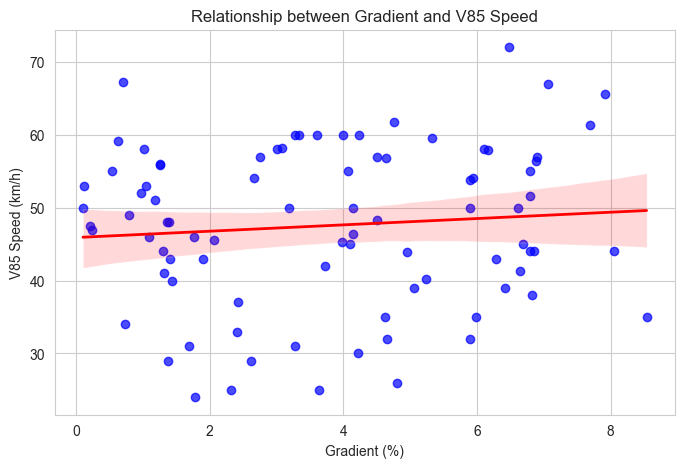

In [4]:
sns.set_style("whitegrid")

# Gradient vs Speed
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df["Gradient"],
    y=df["V85 Speed"],
    scatter_kws={"color": "blue", "alpha": 0.7},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Relationship between Gradient and V85 Speed")
plt.xlabel("Gradient (%)")
plt.ylabel("V85 Speed (km/h)")
plt.show()

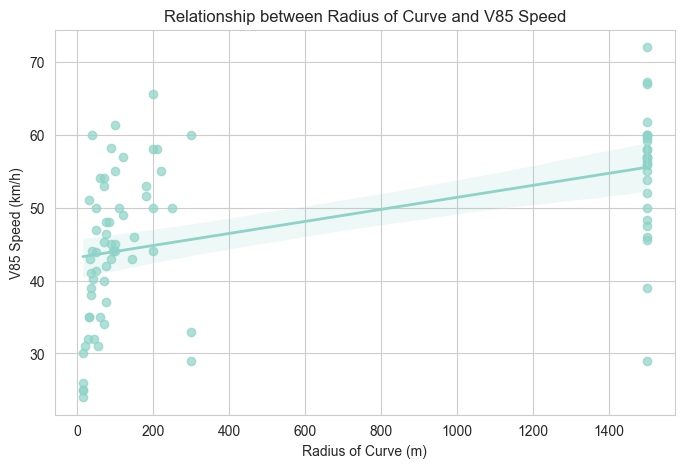

In [5]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df["Radius of Curve"],
    y=df["V85 Speed"],
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)
plt.title("Relationship between Radius of Curve and V85 Speed")
plt.xlabel("Radius of Curve (m)")
plt.ylabel("V85 Speed (km/h)")
plt.show()

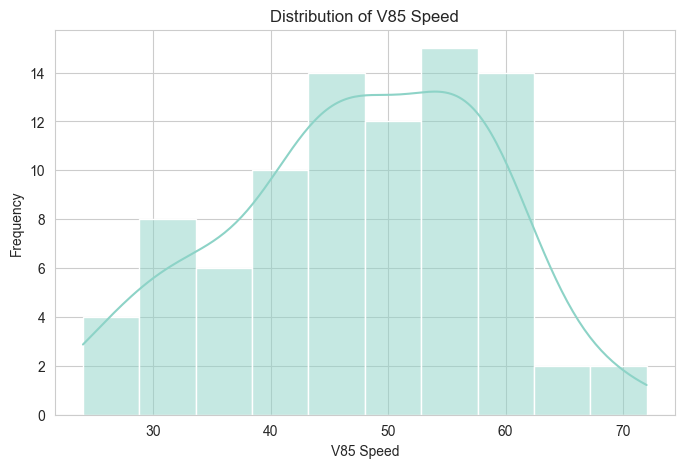

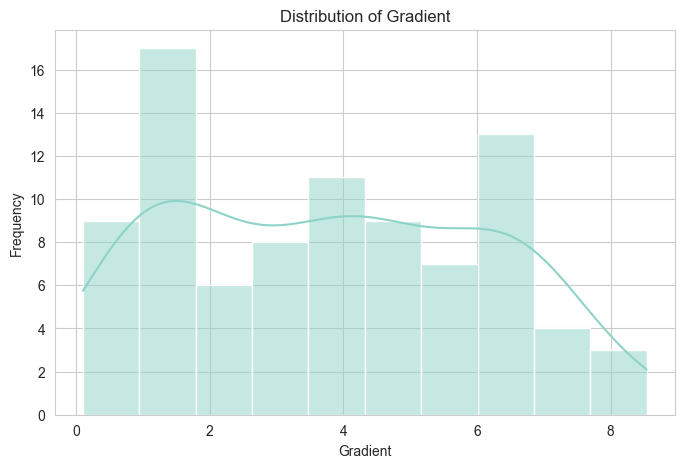

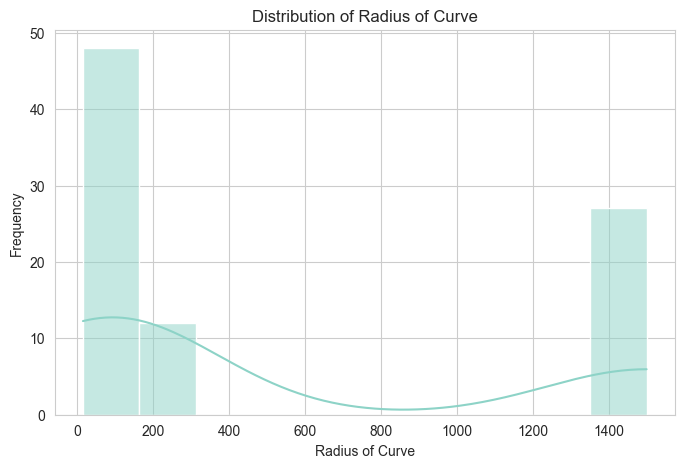

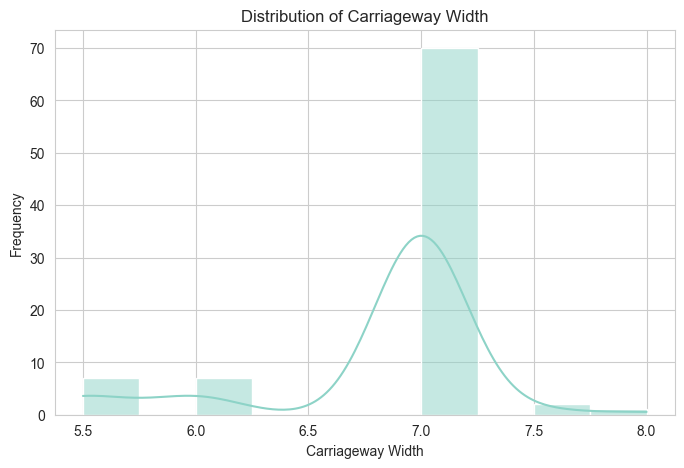

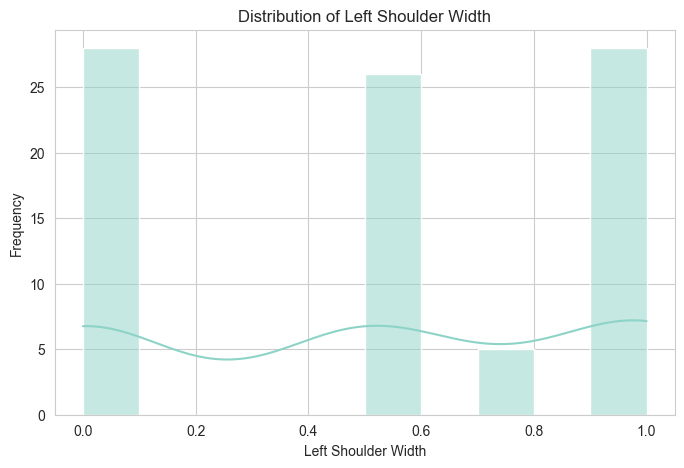

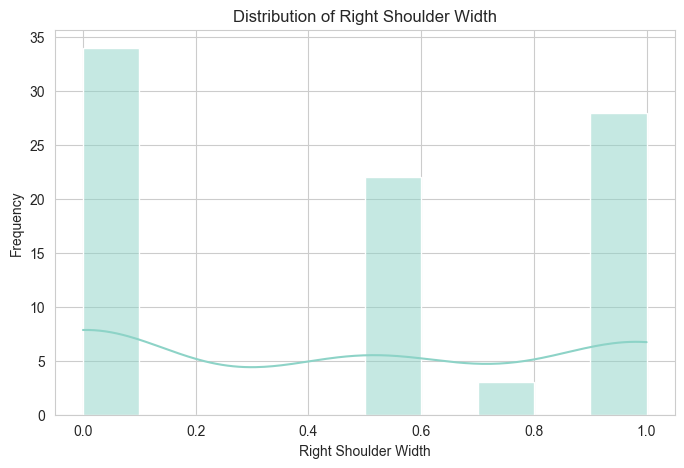

In [29]:
numeric_cols = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=10, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

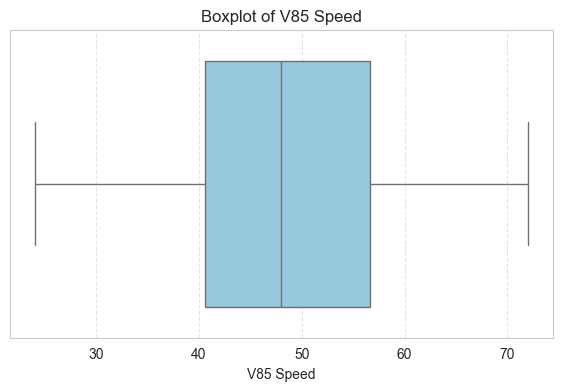

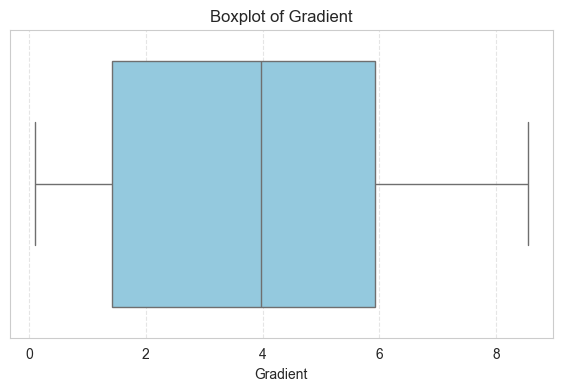

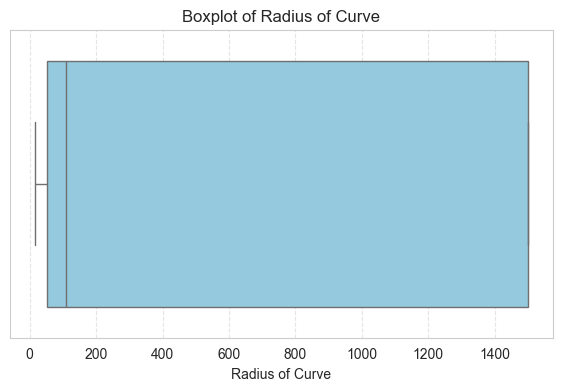

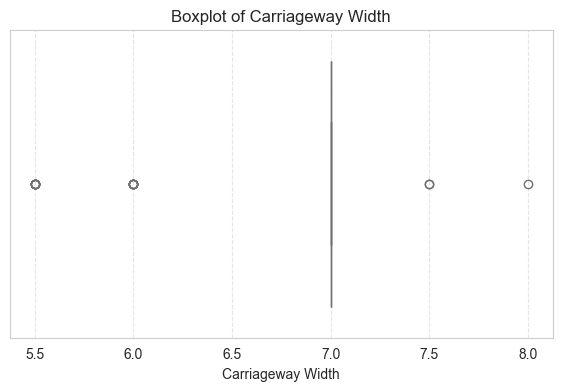

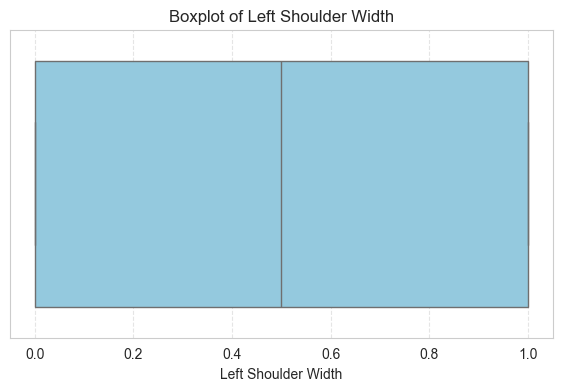

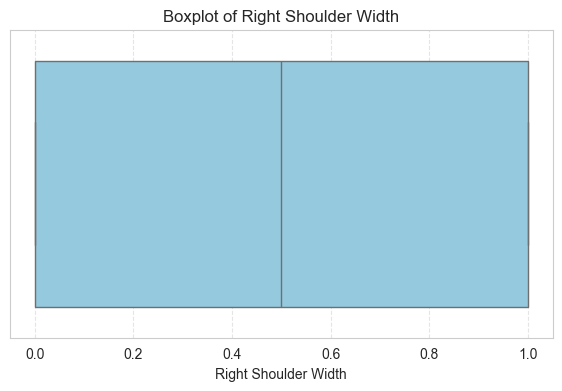

In [30]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[col],
        color="skyblue"
    )

    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.xlabel(col)

    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.show()

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
V85 Speed,1.000000,0.091917,0.493327,0.094946,-0.035119,-0.090205
Gradient,0.091917,1.000000,-0.073394,-0.094351,-0.137775,-0.135055
Radius of Curve,0.493327,-0.073394,1.000000,0.192372,0.005057,-0.038373
Carriageway Width,0.094946,-0.094351,0.192372,1.000000,-0.201258,-0.267423
Left Shoulder Width,-0.035119,-0.137775,0.005057,-0.201258,1.000000,0.491390
Right Shoulder Width,-0.090205,-0.135055,-0.038373,-0.267423,0.491390,1.000000


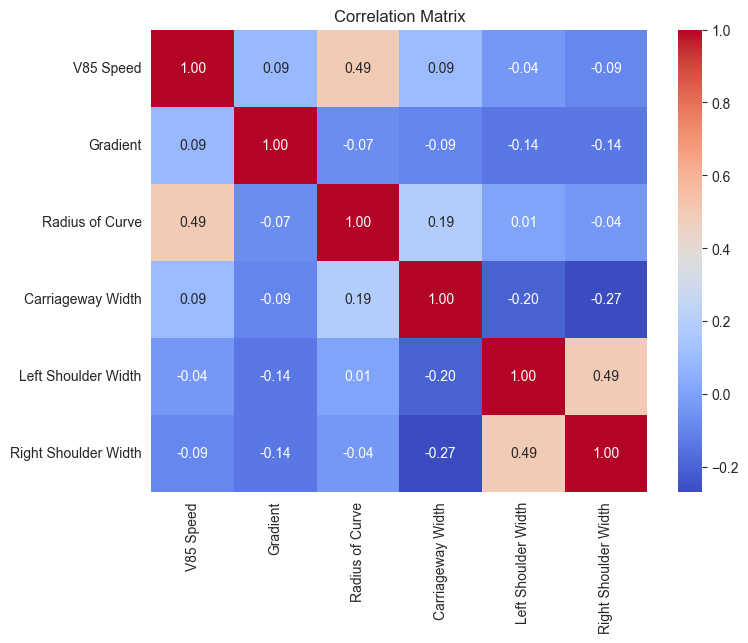

In [8]:
corr_df = df[[
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",   # ← comma added here
]]

corr_matrix = corr_df.corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [13]:
model_df = df[[
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Type"
]].copy()

display(model_df.head())

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type,Right Shoulder Type
0,35.00,8.540,30,5.5,1.0,1.0,Paved,Paved
1,39.00,6.420,35,5.5,1.0,1.0,Paved,Paved
2,37.00,2.420,75,5.5,1.0,1.0,Gravel,Gravel
3,46.35,4.140,75,5.5,1.0,1.0,Paved,Paved
4,40.15,5.235,42,7.0,1.0,1.0,Paved,Gravel


In [14]:
model_df = pd.get_dummies(
    model_df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Dataset after encoding:")
display(model_df.head())

print("Columns after encoding:")
print(model_df.columns.tolist())

Dataset after encoding:


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,35.00,8.540,30,5.5,1.0,1.0,False,True,False,True
1,39.00,6.420,35,5.5,1.0,1.0,False,True,False,True
2,37.00,2.420,75,5.5,1.0,1.0,True,False,True,False
3,46.35,4.140,75,5.5,1.0,1.0,False,True,False,True
4,40.15,5.235,42,7.0,1.0,1.0,False,True,True,False


Columns after encoding:
['V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Right Shoulder Width', 'Left Shoulder Type_Gravel', 'Left Shoulder Type_Paved', 'Right Shoulder Type_Gravel', 'Right Shoulder Type_Paved']


In [15]:
X = model_df.drop(columns=["V85 Speed"])
y = model_df["V85 Speed"]

X = X.astype(float)

print("Predictor variables:")
display(pd.DataFrame({"Variable": X.columns}))

print("X shape:", X.shape)
print("y shape:", y.shape)

Predictor variables:


,Variable
0,Gradient
1,Radius of Curve
2,Carriageway Width
3,Left Shoulder Width
4,Right Shoulder Width
5,Left Shoulder Type_Gravel
6,Left Shoulder Type_Paved
7,Right Shoulder Type_Gravel
8,Right Shoulder Type_Paved


X shape: (87, 9)
y shape: (87,)


In [16]:
X_vif = sm.add_constant(X)

vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("VIF Table:")
display(vif_table)

VIF Table:


,Variable,VIF
0,const,258.754057
1,Gradient,1.103525
2,Radius of Curve,1.062075
3,Carriageway Width,1.186908
4,Left Shoulder Width,47.385557
5,Right Shoulder Width,56.228907
6,Left Shoulder Type_Gravel,24.817107
7,Left Shoulder Type_Paved,28.953457
8,Right Shoulder Type_Gravel,20.838889
9,Right Shoulder Type_Paved,34.507811


In [17]:
model_df = df[[
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]].copy()

In [18]:
X = model_df.drop(columns=["V85 Speed"])
y = model_df["V85 Speed"]

X = X.astype(float)

X_vif = sm.add_constant(X)

vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_table)

,Variable,VIF
0,const,237.986739
1,Gradient,1.050225
2,Radius of Curve,1.043381
3,Carriageway Width,1.146250
4,Left Shoulder Width,1.341763
5,Right Shoulder Width,1.387665


In [25]:
from sklearn.model_selection import train_test_split

# Define X and y
X = model_df.drop(columns=["V85 Speed"])
y = model_df["V85 Speed"]

# Ensure numeric
X = X.astype(float)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (69, 5)
Testing set: (18, 5)


In [26]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Prediction
y_pred_mlr = mlr.predict(X_test)

In [27]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_mlr = r2_score(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)

print("MLR Results:")
print("R2 Score:", r2_mlr)
print("RMSE:", rmse_mlr)
print("MAE:", mae_mlr)

MLR Results:
R2 Score: 0.11473866125549981
RMSE: 8.173340452233134
MAE: 6.587018025628851


In [28]:
coeff_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": mlr.coef_
})

print("Coefficient Table:")
display(coeff_df)

print("Intercept:", mlr.intercept_)

Coefficient Table:


,Variable,Coefficient
0,Gradient,0.828347
1,Radius of Curve,0.008223
2,Carriageway Width,0.354487
3,Left Shoulder Width,0.679727
4,Right Shoulder Width,0.092484


Intercept: 37.18892417341246


In [31]:
X = model_df.drop(columns=["V85 Speed"])
y = model_df["V85 Speed"]

X = X.astype(float)

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

r2_scores = cross_val_score(
    mlr,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R2 Scores for each fold:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("Std R2:", r2_scores.std())

R2 Scores for each fold: [-1.03370257  0.34514273  0.10200859  0.15916509 -0.3635275 ]
Mean R2: -0.158182731382177
Std R2: 0.4960740161420179


In [34]:
rmse_scores = np.sqrt(
    -cross_val_score(
        mlr,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
)

print("RMSE for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

RMSE for each fold: [ 8.97899607 10.07660804 11.69693006  9.47131978 12.31571328]
Mean RMSE: 10.507913446162446


In [35]:
mae_scores = -cross_val_score(
    mlr,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("MAE for each fold:", mae_scores)
print("Mean MAE:", mae_scores.mean())

MAE for each fold: [ 7.78246854  8.10519166 10.12263056  7.35829704  9.69263199]
Mean MAE: 8.612243956915659


In [36]:
cv_results = pd.DataFrame({
    "Fold": range(1, 6),
    "R2": r2_scores,
    "RMSE": rmse_scores,
    "MAE": mae_scores
})

display(cv_results)

print("\nAverage Results:")
print("Mean R2:", r2_scores.mean())
print("Mean RMSE:", rmse_scores.mean())
print("Mean MAE:", mae_scores.mean())

,Fold,R2,RMSE,MAE
0,1,-1.033703,8.978996,7.782469
1,2,0.345143,10.076608,8.105192
2,3,0.102009,11.696930,10.122631
3,4,0.159165,9.471320,7.358297
4,5,-0.363527,12.315713,9.692632



Average Results:
Mean R2: -0.158182731382177
Mean RMSE: 10.507913446162446
Mean MAE: 8.612243956915659


In [37]:
X = model_df.drop(columns=["V85 Speed"])
y = model_df["V85 Speed"]

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [39]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print("R2 Score:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Random Forest Results:
R2 Score: 0.0592751952650451
RMSE: 8.425489430393148
MAE: 6.674261111111112


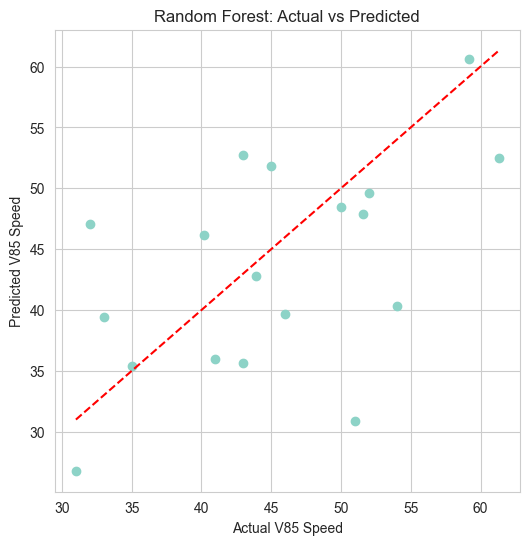

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("Random Forest: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [41]:
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df)

,Variable,Importance
1,Radius of Curve,0.577524
0,Gradient,0.330276
3,Left Shoulder Width,0.043918
4,Right Shoulder Width,0.037949
2,Carriageway Width,0.010332


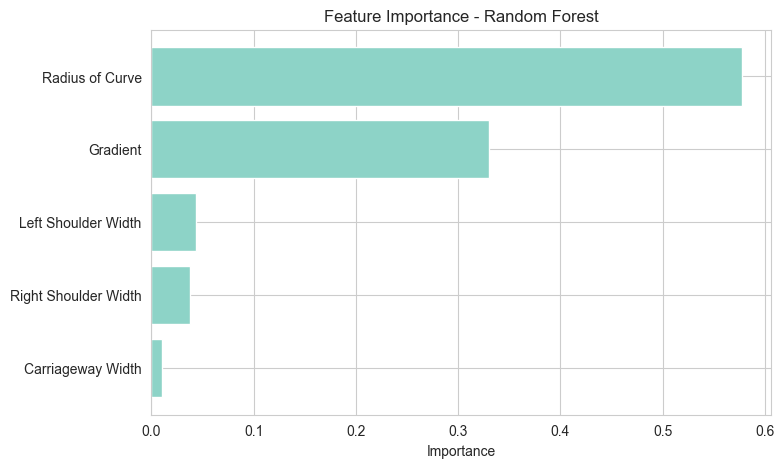

In [42]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Variable"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [43]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

rf_cv = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_

print("Best Parameters:", rf_cv.best_params_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [44]:
y_pred_rf_tuned = best_rf.predict(X_test)

r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("Tuned RF Results:")
print("R2 Score:", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE:", mae_rf_tuned)

Tuned RF Results:
R2 Score: 0.1024040925337033
RMSE: 8.230084083502545
MAE: 6.280692841749272


In [45]:
#SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

In [47]:
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("SVR Results:")
print("R2 Score:", r2_svr)
print("RMSE:", rmse_svr)
print("MAE:", mae_svr)

SVR Results:
R2 Score: -0.05930470003719379
RMSE: 8.940756970660479
MAE: 7.322686833211814


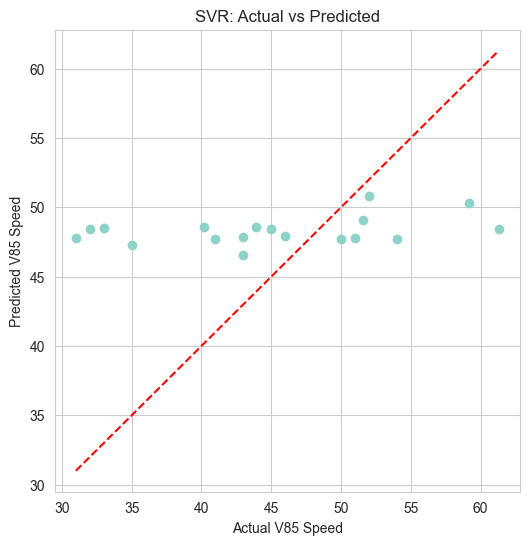

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("SVR: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    "C": [1, 10, 100],
    "epsilon": [0.1, 0.5],
    "kernel": ["rbf"],
    "gamma": ["scale"]
}

svr = SVR()

svr_cv = GridSearchCV(
    svr,
    param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_cv.fit(X_train_scaled, y_train)

best_svr = svr_cv.best_estimator_

print("Best Parameters:", svr_cv.best_params_)

Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [50]:
y_pred_svr_tuned = best_svr.predict(X_test_scaled)

r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mean_squared_error(y_test, y_pred_svr_tuned))
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("Tuned SVR Results:")
print("R2 Score:", r2_svr_tuned)
print("RMSE:", rmse_svr_tuned)
print("MAE:", mae_svr_tuned)

Tuned SVR Results:
R2 Score: -0.05930470003719379
RMSE: 8.940756970660479
MAE: 7.322686833211814


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [52]:
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost Results:")
print("R2 Score:", r2_xgb)
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)

XGBoost Results:
R2 Score: -0.2893252984956045
RMSE: 9.86381895648984
MAE: 7.759277449713813


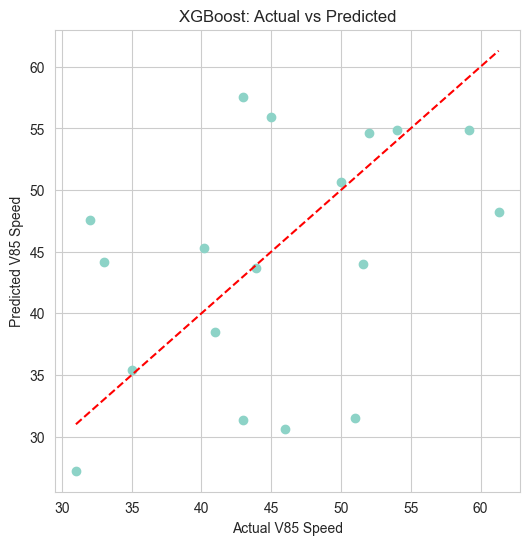

In [53]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")
plt.title("XGBoost: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [54]:
importance_df_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df_xgb)

,Variable,Importance
1,Radius of Curve,0.730613
3,Left Shoulder Width,0.101785
0,Gradient,0.085882
2,Carriageway Width,0.061317
4,Right Shoulder Width,0.020403


In [55]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

xgb_cv = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_cv.fit(X_train, y_train)

best_xgb = xgb_cv.best_estimator_

print("Best Parameters:", xgb_cv.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50, 'subsample': 1.0}


In [56]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Results:")
print("R2 Score:", r2_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("MAE:", mae_xgb_tuned)

Tuned XGBoost Results:
R2 Score: 0.06516093635200648
RMSE: 8.399090605098309
MAE: 6.62034117380778


In [57]:
comparison_df = pd.DataFrame([
    {"Model": "MLR", "R2": r2_mlr, "RMSE": rmse_mlr, "MAE": mae_mlr},

    {"Model": "RF (Basic)", "R2": r2_rf, "RMSE": rmse_rf, "MAE": mae_rf},
    {"Model": "RF (Tuned)", "R2": r2_rf_tuned, "RMSE": rmse_rf_tuned, "MAE": mae_rf_tuned},

    {"Model": "SVR (Basic)", "R2": r2_svr, "RMSE": rmse_svr, "MAE": mae_svr},
    {"Model": "SVR (Tuned)", "R2": r2_svr_tuned, "RMSE": rmse_svr_tuned, "MAE": mae_svr_tuned},

    {"Model": "XGB (Basic)", "R2": r2_xgb, "RMSE": rmse_xgb, "MAE": mae_xgb},
    {"Model": "XGB (Tuned)", "R2": r2_xgb_tuned, "RMSE": rmse_xgb_tuned, "MAE": mae_xgb_tuned}
])

# Round values
comparison_df["R2"] = comparison_df["R2"].round(3)
comparison_df["RMSE"] = comparison_df["RMSE"].round(2)
comparison_df["MAE"] = comparison_df["MAE"].round(2)

# Sort by best R2
comparison_df = comparison_df.sort_values(by="R2", ascending=False)

display(comparison_df)

,Model,R2,RMSE,MAE
0,MLR,0.115,8.17,6.59
2,RF (Tuned),0.102,8.23,6.28
6,XGB (Tuned),0.065,8.40,6.62
1,RF (Basic),0.059,8.43,6.67
3,SVR (Basic),-0.059,8.94,7.32
4,SVR (Tuned),-0.059,8.94,7.32
5,XGB (Basic),-0.289,9.86,7.76


In [58]:
comparison_df = pd.DataFrame([
    ["MLR", r2_mlr, rmse_mlr, mae_mlr],
    ["RF (Basic)", r2_rf, rmse_rf, mae_rf],
    ["RF (Tuned)", r2_rf_tuned, rmse_rf_tuned, mae_rf_tuned],
    ["SVR (Basic)", r2_svr, rmse_svr, mae_svr],
    ["SVR (Tuned)", r2_svr_tuned, rmse_svr_tuned, mae_svr_tuned],
    ["XGBoost (Basic)", r2_xgb, rmse_xgb, mae_xgb],
    ["XGBoost (Tuned)", r2_xgb_tuned, rmse_xgb_tuned, mae_xgb_tuned]
], columns=["Model", "R² Score", "RMSE (km/h)", "MAE (km/h)"])

# Round values
comparison_df = comparison_df.round(3)

# Sort by best R²
comparison_df = comparison_df.sort_values(by="R² Score", ascending=False)

display(comparison_df)

,Model,R² Score,RMSE (km/h),MAE (km/h)
0,MLR,0.115,8.173,6.587
2,RF (Tuned),0.102,8.230,6.281
6,XGBoost (Tuned),0.065,8.399,6.620
1,RF (Basic),0.059,8.425,6.674
3,SVR (Basic),-0.059,8.941,7.323
4,SVR (Tuned),-0.059,8.941,7.323
5,XGBoost (Basic),-0.289,9.864,7.759
